
LORENZ CHAOTIC RGB IMAGE ENCRYPTION

UPLOAD RGB IMAGE
You can upload an image of any size.


Saving test img.jpg to test img.jpg
Uploaded: test img.jpg

IMAGE INFORMATION
--------------------------------------------------
Original format : JPEG
Original mode   : RGB
Original size   : (250, 334)
Width           : 250
Height          : 334
Channels        : 3
Type            : 8-bit RGB
Total pixels    : 83,500
Image validation: PASS

Generating 83,500 Lorenz samples...
Lorenz generation: PASS
16-bit conversion: PASS
8-bit RGB key generation: PASS

SAMPLE LORENZ VALUES
--------------------------------------------------------------------------------
Index   X           Y           Z           X16       Y16       Z16       
--------------------------------------------------------------------------------
0       1.000000    1.000000    1.000000    256       256       256       
1       1.000000    1.260000    0.983333    256       323       252       
2       1.026000    1.517567    0.969711    263       388       248       
3       1.075157    1.779722    0.959422    275       456

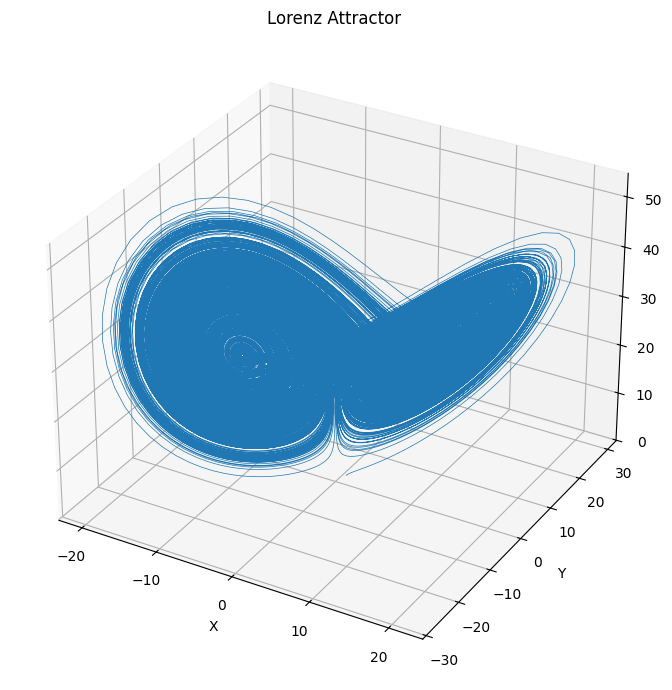

Lorenz plot saved: lorenz_rgb_results/lorenz_attractor.png

Encrypting RGB image...
Encryption: PASS

Decrypting RGB image...
Decryption completed.

IMAGE ENCRYPTION RESULTS
Image dimensions   : 250 × 334
Total pixels       : 83,500
Different pixels   : 0
Maximum difference : 0
Hash check         : PASS
Decryption check   : PASS

Test-vector file created: lorenz_rgb_results/rgb_test_vectors.csv


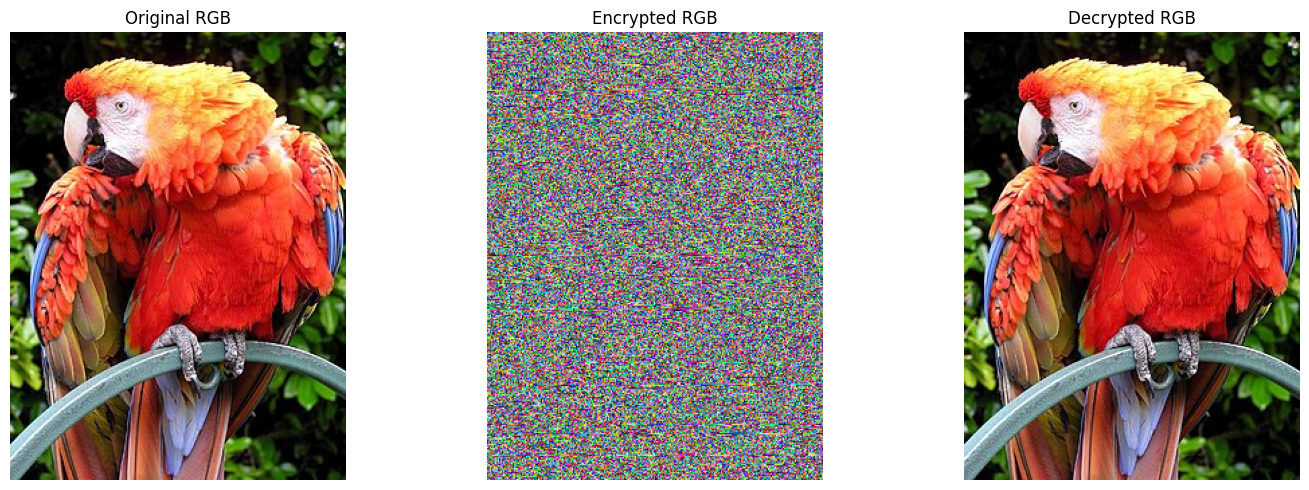


GENERATED FILES
lorenz_rgb_results/original_rgb.png
lorenz_rgb_results/encrypted_rgb.png
lorenz_rgb_results/decrypted_rgb.png
lorenz_rgb_results/rgb_test_vectors.csv
lorenz_rgb_results/image_comparison.png
lorenz_rgb_results/lorenz_attractor.png

FINAL RESULT: PASS

All Lorenz RGB encryption operations completed.


In [1]:
import numpy as np
import csv
import hashlib
from pathlib import Path

from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

SIGMA = 10.0
RHO = 28.0
BETA = 8.0 / 3.0

X0 = 1.0
Y0 = 1.0
Z0 = 1.0

DT = 0.01

OUTPUT_DIR = Path("lorenz_rgb_results")
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# LORENZ EQUATIONS
# ============================================================

def lorenz_derivatives(x, y, z):

    dx = SIGMA * (y - x)
    dy = x * (RHO - z) - y
    dz = x * y - BETA * z

    return dx, dy, dz


# ============================================================
# GENERATE LORENZ ATTRACTOR
# ============================================================

def generate_lorenz(num_samples):

    x = np.zeros(num_samples)
    y = np.zeros(num_samples)
    z = np.zeros(num_samples)

    x[0] = X0
    y[0] = Y0
    z[0] = Z0

    for i in range(num_samples - 1):

        dx, dy, dz = lorenz_derivatives(
            x[i],
            y[i],
            z[i]
        )

        x[i + 1] = x[i] + DT * dx
        y[i + 1] = y[i] + DT * dy
        z[i + 1] = z[i] + DT * dz

    return x, y, z


# ============================================================
# FLOATING POINT → 16-BIT Q8.8
# ============================================================

def convert_to_16bit(values):

    return np.round(
        values * 256
    ).astype(np.uint16)


# ============================================================
# 16-BIT → 8-BIT KEY
#
# Upper 8 bits XOR Lower 8 bits
# ============================================================

def convert_16bit_to_8bit(values_16):

    upper_8 = (
        values_16 >> 8
    ).astype(np.uint8)

    lower_8 = (
        values_16 & 0xFF
    ).astype(np.uint8)

    key_8 = np.bitwise_xor(
        upper_8,
        lower_8
    )

    return upper_8, lower_8, key_8


# ============================================================
# UPLOAD IMAGE
# ============================================================

def upload_image():

    print("\nUPLOAD RGB IMAGE")
    print("You can upload an image of any size.")

    uploaded = files.upload()

    if not uploaded:
        raise RuntimeError(
            "No image was uploaded."
        )

    filename = list(
        uploaded.keys()
    )[0]

    print(f"Uploaded: {filename}")

    return filename


# ============================================================
# LOAD AND VALIDATE IMAGE
# ============================================================

def load_image(filename):

    image = Image.open(filename)

    print("\nIMAGE INFORMATION")
    print("-" * 50)

    print(
        f"Original format : {image.format}"
    )

    print(
        f"Original mode   : {image.mode}"
    )

    print(
        f"Original size   : {image.size}"
    )

    image = image.convert("RGB")

    pixels = np.array(
        image,
        dtype=np.uint8
    )

    height, width, channels = (
        pixels.shape
    )

    print(
        f"Width           : {width}"
    )

    print(
        f"Height          : {height}"
    )

    print(
        f"Channels        : {channels}"
    )

    print(
        "Type            : 8-bit RGB"
    )

    print(
        f"Total pixels    : {width * height:,}"
    )

    assert channels == 3
    assert pixels.dtype == np.uint8

    print(
        "Image validation: PASS"
    )

    return pixels


# ============================================================
# GENERATE RGB KEYS
# ============================================================

def generate_rgb_keys(x, y, z):

    x16 = convert_to_16bit(x)
    y16 = convert_to_16bit(y)
    z16 = convert_to_16bit(z)

    x_upper, x_lower, red_key = (
        convert_16bit_to_8bit(x16)
    )

    y_upper, y_lower, green_key = (
        convert_16bit_to_8bit(y16)
    )

    z_upper, z_lower, blue_key = (
        convert_16bit_to_8bit(z16)
    )

    return (
        x16,
        y16,
        z16,
        x_upper,
        x_lower,
        y_upper,
        y_lower,
        z_upper,
        z_lower,
        red_key,
        green_key,
        blue_key
    )


# ============================================================
# DISPLAY SAMPLE LORENZ VALUES
# ============================================================

def display_samples(
    x,
    y,
    z,
    x16,
    y16,
    z16
):

    print("\nSAMPLE LORENZ VALUES")
    print("-" * 80)

    print(
        f"{'Index':<8}"
        f"{'X':<12}"
        f"{'Y':<12}"
        f"{'Z':<12}"
        f"{'X16':<10}"
        f"{'Y16':<10}"
        f"{'Z16':<10}"
    )

    print("-" * 80)

    for i in range(
        min(5, len(x))
    ):

        print(
            f"{i:<8}"
            f"{x[i]:<12.6f}"
            f"{y[i]:<12.6f}"
            f"{z[i]:<12.6f}"
            f"{int(x16[i]):<10}"
            f"{int(y16[i]):<10}"
            f"{int(z16[i]):<10}"
        )


# ============================================================
# DISPLAY 16-BIT → 8-BIT CONVERSION
# ============================================================

def display_key_conversion(
    x16,
    y16,
    z16,
    red_key,
    green_key,
    blue_key
):

    print("\nKEY CONVERSION")
    print("-" * 110)

    print(
        f"{'Index':<8}"
        f"{'X16':<18}"
        f"{'R Key':<15}"
        f"{'Y16':<18}"
        f"{'G Key':<15}"
        f"{'Z16':<18}"
        f"{'B Key':<15}"
    )

    print(
        f"{'':<8}"
        f"{'Decimal / Hex':<18}"
        f"{'Decimal / Hex':<15}"
        f"{'Decimal / Hex':<18}"
        f"{'Decimal / Hex':<15}"
        f"{'Decimal / Hex':<18}"
        f"{'Decimal / Hex':<15}"
    )

    print("-" * 110)

    for i in range(
        min(5, len(x16))
    ):

        x16_text = (
            f"{int(x16[i])} / 0x{int(x16[i]):04X}"
        )

        r_text = (
            f"{int(red_key[i])} / 0x{int(red_key[i]):02X}"
        )

        y16_text = (
            f"{int(y16[i])} / 0x{int(y16[i]):04X}"
        )

        g_text = (
            f"{int(green_key[i])} / "
            f"0x{int(green_key[i]):02X}"
        )

        z16_text = (
            f"{int(z16[i])} / 0x{int(z16[i]):04X}"
        )

        b_text = (
            f"{int(blue_key[i])} / "
            f"0x{int(blue_key[i]):02X}"
        )

        print(
            f"{i:<8}"
            f"{x16_text:<18}"
            f"{r_text:<15}"
            f"{y16_text:<18}"
            f"{g_text:<15}"
            f"{z16_text:<18}"
            f"{b_text:<15}"
        )


# ============================================================
# DISPLAY RGB KEYS
# ============================================================

def display_rgb_keys(
    red_key,
    green_key,
    blue_key
):

    print("\nGENERATED RGB KEYS")
    print("-" * 60)

    print(
        f"{'Index':<10}"
        f"{'Red':<15}"
        f"{'Green':<15}"
        f"{'Blue':<15}"
    )

    print("-" * 60)

    for i in range(
        min(5, len(red_key))
    ):

        red_text = (
            f"{int(red_key[i])} "
            f"(0x{int(red_key[i]):02X})"
        )

        green_text = (
            f"{int(green_key[i])} "
            f"(0x{int(green_key[i]):02X})"
        )

        blue_text = (
            f"{int(blue_key[i])} "
            f"(0x{int(blue_key[i]):02X})"
        )

        print(
            f"{i:<10}"
            f"{red_text:<15}"
            f"{green_text:<15}"
            f"{blue_text:<15}"
        )


# ============================================================
# ENCRYPT IMAGE
# ============================================================

def encrypt_image(
    image,
    red_key,
    green_key,
    blue_key
):

    pixels = image.reshape(
        -1,
        3
    )

    encrypted = np.empty_like(
        pixels
    )

    encrypted[:, 0] = (
        pixels[:, 0] ^ red_key
    )

    encrypted[:, 1] = (
        pixels[:, 1] ^ green_key
    )

    encrypted[:, 2] = (
        pixels[:, 2] ^ blue_key
    )

    return encrypted.reshape(
        image.shape
    )


# ============================================================
# DECRYPT IMAGE
# ============================================================

def decrypt_image(
    encrypted,
    red_key,
    green_key,
    blue_key
):

    pixels = encrypted.reshape(
        -1,
        3
    )

    decrypted = np.empty_like(
        pixels
    )

    decrypted[:, 0] = (
        pixels[:, 0] ^ red_key
    )

    decrypted[:, 1] = (
        pixels[:, 1] ^ green_key
    )

    decrypted[:, 2] = (
        pixels[:, 2] ^ blue_key
    )

    return decrypted.reshape(
        encrypted.shape
    )


# ============================================================
# SAVE IMAGE
# ============================================================

def save_image(
    array,
    filename
):

    Image.fromarray(
        array
    ).save(
        OUTPUT_DIR / filename
    )


# ============================================================
# SHA-256 HASH
# ============================================================

def calculate_hash(array):

    return hashlib.sha256(
        array.tobytes()
    ).hexdigest()


# ============================================================
# GENERATE CSV TEST VECTORS
# ============================================================

def generate_test_vectors(
    original,
    encrypted,
    decrypted,
    x,
    y,
    z,
    x16,
    y16,
    z16,
    red_key,
    green_key,
    blue_key
):

    filename = (
        OUTPUT_DIR /
        "rgb_test_vectors.csv"
    )

    original_flat = (
        original.reshape(-1, 3)
    )

    encrypted_flat = (
        encrypted.reshape(-1, 3)
    )

    decrypted_flat = (
        decrypted.reshape(-1, 3)
    )

    with open(
        filename,
        "w",
        newline=""
    ) as file:

        writer = csv.writer(file)

        writer.writerow([
            "index",

            "x",
            "y",
            "z",

            "x16_decimal",
            "x16_hex",
            "x16_binary",

            "y16_decimal",
            "y16_hex",
            "y16_binary",

            "z16_decimal",
            "z16_hex",
            "z16_binary",

            "red_key_decimal",
            "red_key_hex",
            "red_key_binary",

            "green_key_decimal",
            "green_key_hex",
            "green_key_binary",

            "blue_key_decimal",
            "blue_key_hex",
            "blue_key_binary",

            "original_r",
            "original_g",
            "original_b",

            "encrypted_r",
            "encrypted_g",
            "encrypted_b",

            "decrypted_r",
            "decrypted_g",
            "decrypted_b"
        ])

        for i in range(
            len(x)
        ):

            writer.writerow([

                i,

                x[i],
                y[i],
                z[i],

                int(x16[i]),
                f"{int(x16[i]):04X}",
                f"{int(x16[i]):016b}",

                int(y16[i]),
                f"{int(y16[i]):04X}",
                f"{int(y16[i]):016b}",

                int(z16[i]),
                f"{int(z16[i]):04X}",
                f"{int(z16[i]):016b}",

                int(red_key[i]),
                f"{int(red_key[i]):02X}",
                f"{int(red_key[i]):08b}",

                int(green_key[i]),
                f"{int(green_key[i]):02X}",
                f"{int(green_key[i]):08b}",

                int(blue_key[i]),
                f"{int(blue_key[i]):02X}",
                f"{int(blue_key[i]):08b}",

                int(original_flat[i, 0]),
                int(original_flat[i, 1]),
                int(original_flat[i, 2]),

                int(encrypted_flat[i, 0]),
                int(encrypted_flat[i, 1]),
                int(encrypted_flat[i, 2]),

                int(decrypted_flat[i, 0]),
                int(decrypted_flat[i, 1]),
                int(decrypted_flat[i, 2])
            ])

    print(
        f"\nTest-vector file created: {filename}"
    )

    return filename


# ============================================================
# LORENZ ATTRACTOR PLOT
# ============================================================

def plot_lorenz(
    x,
    y,
    z
):

    figure = plt.figure(
        figsize=(10, 7)
    )

    axis = figure.add_subplot(
        111,
        projection="3d"
    )

    axis.plot(
        x,
        y,
        z,
        linewidth=0.5
    )

    axis.set_title(
        "Lorenz Attractor"
    )

    axis.set_xlabel("X")
    axis.set_ylabel("Y")
    axis.set_zlabel("Z")

    plt.tight_layout()

    filename = (
        OUTPUT_DIR /
        "lorenz_attractor.png"
    )

    plt.savefig(
        filename,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Lorenz plot saved: {filename}"
    )


# ============================================================
# MAIN PROGRAM
# ============================================================

print("\n" + "=" * 60)
print("LORENZ CHAOTIC RGB IMAGE ENCRYPTION")
print("=" * 60)


# ------------------------------------------------------------
# Upload image
# ------------------------------------------------------------

filename = upload_image()

original = load_image(
    filename
)

height, width, channels = (
    original.shape
)

total_pixels = (
    height * width
)


# ------------------------------------------------------------
# Generate Lorenz samples
# ------------------------------------------------------------

print(
    f"\nGenerating {total_pixels:,} "
    f"Lorenz samples..."
)

x, y, z = generate_lorenz(
    total_pixels
)

print(
    "Lorenz generation: PASS"
)


# ------------------------------------------------------------
# Convert Lorenz values
# ------------------------------------------------------------

(
    x16,
    y16,
    z16,
    x_upper,
    x_lower,
    y_upper,
    y_lower,
    z_upper,
    z_lower,
    red_key,
    green_key,
    blue_key
) = generate_rgb_keys(
    x,
    y,
    z
)

print(
    "16-bit conversion: PASS"
)

print(
    "8-bit RGB key generation: PASS"
)


# ------------------------------------------------------------
# Display samples
# ------------------------------------------------------------

display_samples(
    x,
    y,
    z,
    x16,
    y16,
    z16
)

display_key_conversion(
    x16,
    y16,
    z16,
    red_key,
    green_key,
    blue_key
)

display_rgb_keys(
    red_key,
    green_key,
    blue_key
)


# ------------------------------------------------------------
# Lorenz plot
# ------------------------------------------------------------

print(
    "\nGenerating Lorenz attractor plot..."
)

plot_lorenz(
    x,
    y,
    z
)


# ------------------------------------------------------------
# Encryption
# ------------------------------------------------------------

print(
    "\nEncrypting RGB image..."
)

encrypted = encrypt_image(
    original,
    red_key,
    green_key,
    blue_key
)

print(
    "Encryption: PASS"
)


# ------------------------------------------------------------
# Decryption
# ------------------------------------------------------------

print(
    "\nDecrypting RGB image..."
)

decrypted = decrypt_image(
    encrypted,
    red_key,
    green_key,
    blue_key
)

print(
    "Decryption completed."
)


# ============================================================
# VERIFICATION
# ============================================================

mismatch_mask = (
    original != decrypted
)

mismatch_count = int(
    np.count_nonzero(
        mismatch_mask
    )
)

max_difference = int(
    np.max(
        np.abs(
            original.astype(np.int16)
            -
            decrypted.astype(np.int16)
        )
    )
)

original_hash = calculate_hash(
    original
)

decrypted_hash = calculate_hash(
    decrypted
)

hash_match = (
    original_hash ==
    decrypted_hash
)


print("\n" + "=" * 60)
print("IMAGE ENCRYPTION RESULTS")
print("=" * 60)

print(
    f"Image dimensions   : "
    f"{width} × {height}"
)

print(
    f"Total pixels       : "
    f"{total_pixels:,}"
)

print(
    f"Different pixels   : "
    f"{mismatch_count}"
)

print(
    f"Maximum difference : "
    f"{max_difference}"
)

print(
    f"Hash check         : "
    f"{'PASS' if hash_match else 'FAIL'}"
)

print(
    f"Decryption check   : "
    f"{'PASS' if mismatch_count == 0 else 'FAIL'}"
)

assert mismatch_count == 0
assert max_difference == 0
assert hash_match


# ============================================================
# SAVE OUTPUT IMAGES
# ============================================================

save_image(
    original,
    "original_rgb.png"
)

save_image(
    encrypted,
    "encrypted_rgb.png"
)

save_image(
    decrypted,
    "decrypted_rgb.png"
)


# ============================================================
# TEST VECTOR CSV
# ============================================================

vector_file = generate_test_vectors(
    original,
    encrypted,
    decrypted,
    x,
    y,
    z,
    x16,
    y16,
    z16,
    red_key,
    green_key,
    blue_key
)


# ============================================================
# IMAGE COMPARISON
# ============================================================

plt.figure(
    figsize=(15, 5)
)

plt.subplot(
    1,
    3,
    1
)

plt.imshow(
    original
)

plt.title(
    "Original RGB"
)

plt.axis("off")


plt.subplot(
    1,
    3,
    2
)

plt.imshow(
    encrypted
)

plt.title(
    "Encrypted RGB"
)

plt.axis("off")


plt.subplot(
    1,
    3,
    3
)

plt.imshow(
    decrypted
)

plt.title(
    "Decrypted RGB"
)

plt.axis("off")


plt.tight_layout()

comparison_file = (
    OUTPUT_DIR /
    "image_comparison.png"
)

plt.savefig(
    comparison_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# GENERATED FILES
# ============================================================

print("\n" + "=" * 60)
print("GENERATED FILES")
print("=" * 60)

print(
    OUTPUT_DIR /
    "original_rgb.png"
)

print(
    OUTPUT_DIR /
    "encrypted_rgb.png"
)

print(
    OUTPUT_DIR /
    "decrypted_rgb.png"
)

print(
    vector_file
)

print(
    comparison_file
)

print(
    OUTPUT_DIR /
    "lorenz_attractor.png"
)


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULT: PASS")
print("=" * 60)

print(
    "\nAll Lorenz RGB encryption operations completed."
)